# Ablation IMV — ResNet34 predictions

This notebook uses the saved predictions produced by the original experiment. It renders figures inline and writes reproducible tables/figures to `results/` and `figures/`.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from imv import AblationIMV
from imv.utils import plot_ablation_matrix

ROOT = Path.cwd()
PREDICTIONS = ROOT / "predictions"
FIGURES = ROOT / "figures"
RESULTS = ROOT / "results"
FIGURES.mkdir(exist_ok=True)
RESULTS.mkdir(exist_ok=True)

/Users/valler/miniforge3/envs/imv/lib/python3.11/site-packages/tqdm_joblib/__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
VARIANTS = ["Original", "NoGlobalPooling", "NoLayer4", "NoSkip", "SimplifiedResidualBlock"]
SEEDS = [42, 43, 44, 45, 46]
RESULT_NAME = "resnet34_ablation_imv"

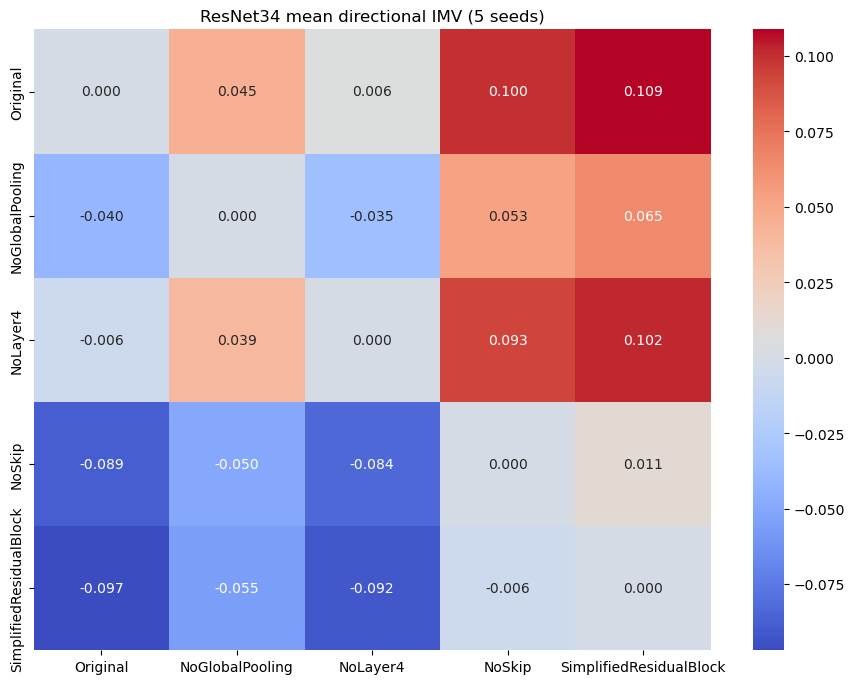

,Original,NoGlobalPooling,NoLayer4,NoSkip,SimplifiedResidualBlock
Original,0.000000,0.045167,0.005861,0.099819,0.108672
NoGlobalPooling,-0.040377,0.000000,-0.034836,0.052874,0.064623
NoLayer4,-0.005818,0.038994,0.000000,0.093347,0.102227
NoSkip,-0.088853,-0.050017,-0.083572,0.000000,0.011032
SimplifiedResidualBlock,-0.096906,-0.055400,-0.091611,-0.005865,0.000000


In [3]:
matrices = []
for seed in SEEDS:
    frames = {}
    for variant in VARIANTS:
        raw = pd.read_csv(PREDICTIONS / f"ResNet34_{variant}_predictions_seed_{seed}.csv")
        frames[variant] = pd.DataFrame({
            "True Label": raw["True_Label"],
            "Positive Probability": raw[f"ResNet34_{variant}_class1_prob"],
        })
    reference = frames["Original"]["True Label"].to_numpy()
    assert all(np.array_equal(frame["True Label"].to_numpy(), reference) for frame in frames.values())
    matrices.append(AblationIMV.calculate_imv_matrix(frames))
mean_matrix = AblationIMV.average_imv_matrices(matrices)
mean_matrix.to_csv(RESULTS / (RESULT_NAME + "_directional.csv"))
fig, ax = plot_ablation_matrix(mean_matrix, figsize=(9, 7), title="ResNet34 mean directional IMV (5 seeds)")
fig.tight_layout(); fig.savefig(FIGURES / (RESULT_NAME + ".png"), dpi=180, bbox_inches="tight")
plt.show()
mean_matrix

## Legacy discrepancy

The original ablation notebook calculated both directions and then copied the upper triangle onto the lower triangle. That makes the displayed matrix symmetric, although `(w_enhanced-w_basic)/w_basic` is directional. The package result below retains direction. `legacy_symmetric` is saved separately only for exact figure comparison.

In [4]:
legacy_symmetric = mean_matrix.copy()
for i in range(len(legacy_symmetric)):
    for j in range(i + 1, len(legacy_symmetric)):
        legacy_symmetric.iloc[j, i] = legacy_symmetric.iloc[i, j]
legacy_symmetric.to_csv(RESULTS / (RESULT_NAME + "_legacy_symmetric.csv"))
legacy_symmetric

,Original,NoGlobalPooling,NoLayer4,NoSkip,SimplifiedResidualBlock
Original,0.000000,0.045167,0.005861,0.099819,0.108672
NoGlobalPooling,0.045167,0.000000,-0.034836,0.052874,0.064623
NoLayer4,0.005861,-0.034836,0.000000,0.093347,0.102227
NoSkip,0.099819,0.052874,0.093347,0.000000,0.011032
SimplifiedResidualBlock,0.108672,0.064623,0.102227,0.011032,0.000000
